# Importing dependencies

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Configuring graphs

In [2]:
plt.rc('font', **{'family':'serif', 'size': 10})
plt.rc('mathtext', **{'fontset':'cm'})
image_resolution = 600
fontsize_label = 12
fontsize_text = 18
fontsize_legend = 10
markers = ['o', 'v', 's', 'X', 'P', 'p', 'D', 'd', 'H', 'h', 'x', '+', '*', '1', '2', '|', '_']
marker_size = 6
cap_size = 3.0
colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal', 'navy', 'maroon', 'lime']

# Thermophysical properties

In [3]:
def rho(temperature, salinity):
    a = [9.999e2, 2.034e-2, -6.162e-3, 2.261e-5, -4.657e-8]
    b = [8.020e2, -2.001, 1.677e-2, -3.060e-5, -1.613e-5]

    temperature_part = a[0] + a[1] * temperature
    temperature_part += a[2] * temperature * temperature
    temperature_part += a[3] * temperature * temperature * temperature
    temperature_part += a[4] * temperature * temperature * temperature * temperature

    salinity_part = b[0] * salinity
    salinity_part += b[1] * salinity * temperature
    salinity_part += b[2] * salinity * temperature * temperature
    salinity_part += b[3] * salinity * temperature * temperature * temperature
    salinity_part += b[4] * salinity * salinity * temperature * temperature

    return temperature_part + salinity_part

# Establishing directories

In [4]:
figures_dir = os.path.join('./figures/A7_e_A8/')

os.system('mkdir -p ' + figures_dir)


0

# Loading the cases

In [5]:
cases = pd.read_csv('A7_e_A8.csv')

def parse_value_with_uncertainty(value):
    if pd.isna(value):
        return np.nan, np.nan

    text = str(value).strip().replace(',', '.')
    if '±' in text:
        value_str, uncertainty_str = [part.strip() for part in text.split('±', 1)]
        return pd.to_numeric(value_str, errors='coerce'), pd.to_numeric(uncertainty_str, errors='coerce')

    numeric_value = pd.to_numeric(text, errors='coerce')
    return numeric_value, np.nan

flux_parsed = cases['J_e [L h^-1 m^-2]'].apply(parse_value_with_uncertainty)
coolant_out_parsed = cases['T_CO,e [°C]'].apply(parse_value_with_uncertainty)

cases['Feed temperature at the inlet (°C)'] = pd.to_numeric(cases['T_EI [°C]'], errors='coerce')
cases['Coolant temperature at the inlet (°C)'] = pd.to_numeric(cases['T_CI [°C]'], errors='coerce')
cases['Feed salinity at the inlet (g/L)'] = pd.to_numeric(cases['S [g L^-1]'], errors='coerce')
cases['Flow rate (L/h)'] = pd.to_numeric(cases['F_FR [L h^-1]'], errors='coerce')

cases['Distilled water flux (L/m²h)'] = flux_parsed.apply(lambda item: item[0])
cases['Distilled water flux uncertainty (L/m²h)'] = flux_parsed.apply(lambda item: item[1]).fillna(0.0)

cases['Coolant temperature at the outlet (°C)'] = coolant_out_parsed.apply(lambda item: item[0])
cases['Coolant temperature at the outlet uncertainty (°C)'] = coolant_out_parsed.apply(lambda item: item[1]).fillna(0.0)

cases['Feed temperature at the outlet (°C)'] = np.nan
cases['Feed temperature at the outlet uncertainty (°C)'] = 0.0

cases['Vacuum pressure (Pa)'] = 50000.0
cases['Membrane area (m²)'] = 12.96
cases['Number of channels'] = 6

cases['Case'] = 'A7A8-' + (cases.index + 1).astype(str)

numeric_columns = [
    'Feed temperature at the inlet (°C)',
    'Coolant temperature at the inlet (°C)',
    'Vacuum pressure (Pa)',
    'Feed salinity at the inlet (g/L)',
    'Membrane area (m²)',
    'Number of channels',
    'Distilled water flux (L/m²h)',
    'Distilled water flux uncertainty (L/m²h)',
    'Feed temperature at the outlet (°C)',
    'Feed temperature at the outlet uncertainty (°C)',
    'Coolant temperature at the outlet (°C)',
    'Coolant temperature at the outlet uncertainty (°C)',
    'Flow rate (L/h)'
]
cases[numeric_columns] = cases[numeric_columns].apply(pd.to_numeric, errors='coerce')

display(cases)


,T_EI [°C],F_FR [L h^-1],T_CI [°C],S [g L^-1],J_e [L h^-1 m^-2],"T_CO,e [°C]",Feed temperature at the inlet (°C),Coolant temperature at the inlet (°C),Feed salinity at the inlet (g/L),Flow rate (L/h),Distilled water flux (L/m²h),Distilled water flux uncertainty (L/m²h),Coolant temperature at the outlet (°C),Coolant temperature at the outlet uncertainty (°C),Feed temperature at the outlet (°C),Feed temperature at the outlet uncertainty (°C),Vacuum pressure (Pa),Membrane area (m²),Number of channels,Case
0,60,400.0,25.0,140.3,0.10,56.8,60,25.0,140.3,400.0,0.10,0.0,56.8,0.0,NaN,0.0,50000.0,12.96,6,A7A8-1
1,60,1100.0,25.0,140.3,0.90,55.2,60,25.0,140.3,1100.0,0.90,0.0,55.2,0.0,NaN,0.0,50000.0,12.96,6,A7A8-2
2,80,400.0,25.0,140.3,0.36,75.1,80,25.0,140.3,400.0,0.36,0.0,75.1,0.0,NaN,0.0,50000.0,12.96,6,A7A8-3
3,80,1100.0,25.0,140.3,1.90,73.4,80,25.0,140.3,1100.0,1.90,0.0,73.4,0.0,NaN,0.0,50000.0,12.96,6,A7A8-4
4,70,750.0,20.0,35.1,1.76,65.7,70,20.0,35.1,750.0,1.76,0.0,65.7,0.0,NaN,0.0,50000.0,12.96,6,A7A8-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,80,750.0,20.0,210.4,0.77,72.9,80,20.0,210.4,750.0,0.77,0.0,72.9,0.0,NaN,0.0,50000.0,12.96,6,A7A8-119
119,80,750.0,30.0,210.4,0.45,73.9,80,30.0,210.4,750.0,0.45,0.0,73.9,0.0,NaN,0.0,50000.0,12.96,6,A7A8-120
120,80,1100.0,25.0,210.4,1.36,72.5,80,25.0,210.4,1100.0,1.36,0.0,72.5,0.0,NaN,0.0,50000.0,12.96,6,A7A8-121
121,60,1100.0,20.0,245.5,0.41,53.7,60,20.0,245.5,1100.0,0.41,0.0,53.7,0.0,NaN,0.0,50000.0,12.96,6,A7A8-122


# Running the cases

In [6]:
def salinity_equation(x, salinity, temperature):
    return rho(temperature, x) * x - salinity

In [7]:
results = pd.DataFrame(columns=[
    'Case', 'Permeate flux (L/m²h)', 'Exp. permeate flux (L/m²h)', 'Hot feedwater outlet temperature (°C)',
    'Exp. hot feedwater outlet temperature (°C)', 'Cold feedwater outlet temperature (°C)', 'Exp. cold feedwater outlet temperature (°C)',
    'Heat flux (W/m²)', 'Vapor heat flux (W/m²)', 'GOR', 'STECth', 'Thermal efficiency (%)'
])

for index, elem in cases.iterrows():
    hot_feedwater_inlet_temperature = elem['Feed temperature at the inlet (°C)']
    cold_feedwater_inlet_temperature = elem['Coolant temperature at the inlet (°C)']
    vacuum_pressure = -abs(elem['Vacuum pressure (Pa)'])

    initial_guess = elem['Feed salinity at the inlet (g/L)'] / 1000.0
    feed_salinity = fsolve(
        salinity_equation,
        initial_guess,
        args=(elem['Feed salinity at the inlet (g/L)'], elem['Feed temperature at the inlet (°C)'])
    )[0]
    cool_salinity = feed_salinity

    flow_rate = elem['Flow rate (L/h)']
    feed_mass_flow_rate = rho(hot_feedwater_inlet_temperature, feed_salinity) * flow_rate / 3600000.0
    cool_mass_flow_rate = rho(cold_feedwater_inlet_temperature, cool_salinity) * flow_rate / 3600000.0

    membrane_area = elem['Membrane area (m²)']
    number_channels = int(elem['Number of channels'])

    print('Salinity = ', str(elem['Feed salinity at the inlet (g/L)']), ' g/L')
    os.system('./bin/vagmd0Dmodel -entry_temperature_feed ' + str(hot_feedwater_inlet_temperature) +
              ' -entry_temperature_cool ' + str(cold_feedwater_inlet_temperature) +
              ' -feed_mass_flow_rate ' + str(feed_mass_flow_rate) +
              ' -cool_mass_flow_rate ' + str(cool_mass_flow_rate) +
              ' -vacuum_pressure ' + str(vacuum_pressure) +
              ' -entry_salinity_feed ' + str(feed_salinity) +
              ' -entry_salinity_cool ' + str(cool_salinity) +
              ' -membrane_area ' + str(membrane_area) +
              ' -number_channels ' + str(number_channels))

    results_file = pd.read_csv('./results/report.csv')
    latest_result = results_file.iloc[-1]

    mass_flux = latest_result.iloc[11]
    film_temperature = latest_result.iloc[4]
    hot_feedwater_outlet_temperature = latest_result.iloc[1]
    cold_feedwater_outlet_temperature = latest_result.iloc[2]
    heat_flux = latest_result.iloc[13]
    vapor_heat_flux = latest_result.iloc[15]
    GOR = latest_result.iloc[17]
    STECth = latest_result.iloc[19]
    thermal_efficiency = latest_result.iloc[18]

    new_row = pd.DataFrame([{
        'Case': elem['Case'],
        'Permeate flux (L/m²h)': 1000.0 * mass_flux / rho(film_temperature, 0.0),
        'Exp. permeate flux (L/m²h)': elem['Distilled water flux (L/m²h)'],
        'Hot feedwater outlet temperature (°C)': hot_feedwater_outlet_temperature,
        'Exp. hot feedwater outlet temperature (°C)': elem['Feed temperature at the outlet (°C)'],
        'Cold feedwater outlet temperature (°C)': cold_feedwater_outlet_temperature,
        'Exp. cold feedwater outlet temperature (°C)': elem['Coolant temperature at the outlet (°C)'],
        'Heat flux (W/m²)': heat_flux,
        'Vapor heat flux (W/m²)': vapor_heat_flux,
        'GOR': GOR,
        'STECth': STECth,
        'Thermal efficiency (%)': thermal_efficiency
    }])
    results = pd.concat([results, new_row], ignore_index=True)


Salinity =  140.3  g/L


/tmp/ipykernel_115129/1880593460.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([results, new_row], ignore_index=True)


Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  35.1  g/L
Salinity =  245.5  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  140.3  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  35.1  g/L
Salinity =  

In [8]:
display(results)

,Case,Permeate flux (L/m²h),Exp. permeate flux (L/m²h),Hot feedwater outlet temperature (°C),Exp. hot feedwater outlet temperature (°C),Cold feedwater outlet temperature (°C),Exp. cold feedwater outlet temperature (°C),Heat flux (W/m²),Vapor heat flux (W/m²),GOR,STECth,Thermal efficiency (%)
0,A7A8-1,0.746103,0.10,30.486689,NaN,54.037859,56.8,982.848891,425.371999,2.102289,271.429568,43.279491
1,A7A8-2,2.184272,0.90,35.143835,NaN,49.472970,55.2,2276.925105,1239.569453,1.262069,450.427764,54.440502
2,A7A8-3,1.585742,0.36,32.071955,NaN,71.557186,75.1,1577.444942,883.357009,3.078056,181.226020,55.999229
3,A7A8-4,4.461952,1.90,38.585868,NaN,65.261132,73.4,3749.520640,2467.343378,1.791458,309.514888,65.804235
4,A7A8-5,2.776157,1.76,29.626217,NaN,59.525542,65.7,2608.794348,1750.474061,2.525299,250.100281,67.098967
...,...,...,...,...,...,...,...,...,...,...,...,...
118,A7A8-119,2.937075,0.77,32.973118,NaN,65.486001,72.9,2846.250889,1510.774939,1.662877,310.096834,53.079472
119,A7A8-120,2.474487,0.45,40.739025,NaN,68.159842,73.9,2377.863357,1270.294176,1.721056,298.941991,53.421664
120,A7A8-121,4.047078,1.36,39.792784,NaN,63.979660,72.5,3570.055988,2070.965590,1.410982,363.748771,58.009331
121,A7A8-122,1.945883,0.41,32.992840,NaN,46.402561,53.7,2414.354872,991.976230,0.799820,638.693169,41.086596


In [9]:
100.0 * (results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

0      646.103152
1      142.696868
2      340.483967
3      134.839584
4       57.736198
          ...    
118    281.438276
119    449.885977
120    197.579259
121    374.605639
122    880.950584
Length: 123, dtype: float64

# Plot the results for different salinities

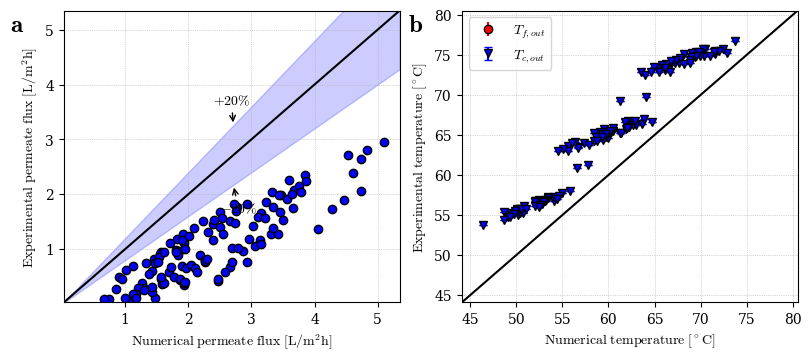

In [10]:
flux_x = results['Permeate flux (L/m²h)'].to_numpy()
flux_y = results['Exp. permeate flux (L/m²h)'].to_numpy()
flux_err = cases['Distilled water flux uncertainty (L/m²h)'].to_numpy()
flux_mask = np.isfinite(flux_x) & np.isfinite(flux_y) & np.isfinite(flux_err)

min_mass_flux = 0.75 * np.nanmin([np.nanmin(flux_x[flux_mask]), np.nanmin(flux_y[flux_mask])])
max_mass_flux = 1.05 * np.nanmax([np.nanmax(flux_x[flux_mask]), np.nanmax(flux_y[flux_mask])])
mass_flux_line = np.linspace(min_mass_flux, max_mass_flux, 100)

hot_x = results['Hot feedwater outlet temperature (°C)'].to_numpy()
hot_y = results['Exp. hot feedwater outlet temperature (°C)'].to_numpy()
hot_err = cases['Feed temperature at the outlet uncertainty (°C)'].to_numpy()
hot_mask = np.isfinite(hot_x) & np.isfinite(hot_y) & np.isfinite(hot_err)

cold_x = results['Cold feedwater outlet temperature (°C)'].to_numpy()
cold_y = results['Exp. cold feedwater outlet temperature (°C)'].to_numpy()
cold_err = cases['Coolant temperature at the outlet uncertainty (°C)'].to_numpy()
cold_mask = np.isfinite(cold_x) & np.isfinite(cold_y) & np.isfinite(cold_err)

temperature_values = np.concatenate([hot_x[hot_mask], hot_y[hot_mask], cold_x[cold_mask], cold_y[cold_mask]])
min_temperature = 0.95 * np.nanmin(temperature_values)
max_temperature = 1.05 * np.nanmax(temperature_values)
temperature_line = np.linspace(min_temperature, max_temperature, 100)

figval, axsval = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

axsval[0].errorbar(
    flux_x[flux_mask],
    flux_y[flux_mask],
    yerr=flux_err[flux_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axsval[0].plot(mass_flux_line, mass_flux_line, color='black')
axsval[0].fill_between(mass_flux_line, 0.8 * mass_flux_line, 1.2 * mass_flux_line, color='blue', alpha=0.2)
axsval[0].annotate(r'$\mathrm{+20\%}$', xy=(mass_flux_line[50], 1.2 * mass_flux_line[50]), xytext=(-15, 15), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].annotate(r'$\mathrm{-20\%}$', xy=(mass_flux_line[50], 0.8 * mass_flux_line[50]), xytext=(-10, -20), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axsval[0].set_xlim(min_mass_flux, max_mass_flux)
axsval[0].set_ylim(min_mass_flux, max_mass_flux)
axsval[0].grid(linestyle='dotted', linewidth=0.5)
axsval[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axsval[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

axsval[1].errorbar(
    hot_x[hot_mask],
    hot_y[hot_mask],
    yerr=hot_err[hot_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axsval[1].errorbar(
    cold_x[cold_mask],
    cold_y[cold_mask],
    yerr=cold_err[cold_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axsval[1].plot(temperature_line, temperature_line, color='black')
axsval[1].set_xlim(min_temperature, max_temperature)
axsval[1].set_ylim(min_temperature, max_temperature)
axsval[1].legend(fontsize=fontsize_legend)
axsval[1].grid(linestyle='dotted', linewidth=0.5)
axsval[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axsval[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

axsval[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axsval[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axsval[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axsval[1].transAxes, fontsize=fontsize_text, fontweight='bold')

figval.savefig(figures_dir + 'validation_salinity.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)


In [11]:
# Quantidade de pontos no gráfico de fluxo de permeado (Gráfico a)
qtd_fluxo = flux_mask.sum()
print(f"Pontos plotados no gráfico de fluxo de permeado: {qtd_fluxo}")

# Quantidade de pontos no gráfico de temperatura (Gráfico b)
qtd_hot = hot_mask.sum()
qtd_cold = cold_mask.sum()
print(f"Pontos Tf,out plotados no gráfico de temperatura: {qtd_hot}")
print(f"Pontos Tc,out plotados no gráfico de temperatura: {qtd_cold}")
print(f"Total de pontos no gráfico de temperatura: {qtd_hot + qtd_cold}")

Pontos plotados no gráfico de fluxo de permeado: 123
Pontos Tf,out plotados no gráfico de temperatura: 0
Pontos Tc,out plotados no gráfico de temperatura: 123
Total de pontos no gráfico de temperatura: 123


In [12]:
import os

# 1. Adiciona uma nova coluna com o desvio percentual absoluto
results['Deviation (%)'] = 100.0 * abs(results['Permeate flux (L/m²h)'] - results['Exp. permeate flux (L/m²h)']) / results['Exp. permeate flux (L/m²h)']

# 2. Cria as máscaras para separar os dados (<= 20% e > 20%)
mask_within_20 = results['Deviation (%)'] <= 20.0
mask_above_20 = results['Deviation (%)'] > 20.0

# 3. Separa os resultados em dois DataFrames distintos
df_within_20 = results[mask_within_20]
df_above_20 = results[mask_above_20]

# 4. Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
df_within_20.to_csv('./results/desvios_ate_20.csv', index=False)
df_above_20.to_csv('./results/desvios_acima_de_20.csv', index=False)

print(f"Arquivos CSV gerados com sucesso!")
print(f"-> Casos com desvio de até 20%: {len(df_within_20)}")
print(f"-> Casos com desvio maior que 20%: {len(df_above_20)}")

Arquivos CSV gerados com sucesso!
-> Casos com desvio de até 20%: 0
-> Casos com desvio maior que 20%: 123


In [13]:
# 3. Recalcula os limites do fluxo de permeado
min_mass_flux_final = 0.75 * np.nanmin([np.nanmin(flux_x[final_mask]), np.nanmin(flux_y[final_mask])])
max_mass_flux_final = 1.05 * np.nanmax([np.nanmax(flux_x[final_mask]), np.nanmax(flux_y[final_mask])])

# AJUSTE: Linha base parte de 0 até um valor muito maior, cruzando toda a tela
mass_flux_line_final = np.linspace(0, max_mass_flux_final * 1.5, 100)

# 4. Recalcula os limites de temperatura
temp_values_final = np.concatenate([
    hot_x[final_mask], hot_y[final_mask], 
    cold_x[final_mask], cold_y[final_mask]
])
min_temp_final = 0.95 * np.nanmin(temp_values_final)
max_temp_final = 1.05 * np.nanmax(temp_values_final)

# AJUSTE: Fazemos o mesmo para a reta de temperaturas
temp_line_final = np.linspace(0, max_temp_final * 1.5, 100)

# 5. Configura a figura com dois gráficos (1 linha, 2 colunas)
fig_final, axs_final = plt.subplots(nrows=1, ncols=2, figsize=(8.0, 3.5), layout='constrained')

# ----------------- Gráfico a: Fluxo de Permeado (Desvio <= 20%) -----------------
axs_final[0].errorbar(
    flux_x[final_mask],
    flux_y[final_mask],
    yerr=flux_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, linestyle='None'
)
axs_final[0].plot(mass_flux_line_final, mass_flux_line_final, color='black')
axs_final[0].fill_between(mass_flux_line_final, 0.8 * mass_flux_line_final, 1.2 * mass_flux_line_final, color='blue', alpha=0.2)

# AJUSTE: Coordenadas calculadas dinamicamente com base na área visível
# Pegamos pontos que estão a 30% (para o -20%) e a 70% (para o +20%) da janela visível
x_range = max_mass_flux_final - min_mass_flux_final
x_down = min_mass_flux_final + 0.30 * x_range
x_up = min_mass_flux_final + 0.70 * x_range

axs_final[0].annotate(r'$\mathrm{+20\%}$', xy=(x_up, 1.2 * x_up), 
                      xytext=(-45, 5), textcoords='offset points', arrowprops=dict(arrowstyle='->'))
axs_final[0].annotate(r'$\mathrm{-20\%}$', xy=(x_down, 0.8 * x_down), 
                      xytext=(0, -30), textcoords='offset points', arrowprops=dict(arrowstyle='->'))

# AJUSTE: Trava os eixos firmemente para recortar as sobras da linha e evitar margens em branco
axs_final[0].set_xlim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].set_ylim(min_mass_flux_final, max_mass_flux_final)
axs_final[0].grid(linestyle='dotted', linewidth=0.5)
axs_final[0].set_xlabel(r'$\mathrm{Numerical\ permeate\ flux\ [L/m^2h]}$')
axs_final[0].set_ylabel(r'$\mathrm{Experimental\ permeate\ flux\ [L/m^2h]}$')

# ----------------- Gráfico b: Temperaturas -----------------
axs_final[1].errorbar(
    hot_x[final_mask],
    hot_y[final_mask],
    yerr=hot_err[final_mask],
    marker=markers[0], markersize=marker_size, markeredgecolor='black',
    color=colors[1], capsize=cap_size, label=r'$T_{f,out}$', linestyle='None'
)
axs_final[1].errorbar(
    cold_x[final_mask],
    cold_y[final_mask],
    yerr=cold_err[final_mask],
    marker=markers[1], markersize=marker_size, markeredgecolor='black',
    color=colors[0], capsize=cap_size, label=r'$T_{c,out}$', linestyle='None'
)
axs_final[1].plot(temp_line_final, temp_line_final, color='black')
axs_final[1].set_xlim(min_temp_final, max_temp_final)
axs_final[1].set_ylim(min_temp_final, max_temp_final)
axs_final[1].legend(fontsize=fontsize_legend)
axs_final[1].grid(linestyle='dotted', linewidth=0.5)
axs_final[1].set_xlabel(r'$\mathrm{Numerical\ temperature\ [^\circ C]}$')
axs_final[1].set_ylabel(r'$\mathrm{Experimental\ temperature\ [^\circ C]}$')

# ----------------- Formatação Final e Salvamento -----------------
axs_final[0].text(-0.16, 0.93, r'$\mathbf{a}$', transform=axs_final[0].transAxes, fontsize=fontsize_text, fontweight='bold')
axs_final[1].text(-0.16, 0.93, r'$\mathbf{b}$', transform=axs_final[1].transAxes, fontsize=fontsize_text, fontweight='bold')

fig_final.savefig(figures_dir + 'validation_strict_20_percent_fixed.svg', dpi=image_resolution, bbox_inches='tight', pad_inches=0.01)

plt.show()

# 6. Imprime a quantidade
qtd_final = final_mask.sum()
print(f"Total de experimentos com informações completas e desvio <= 20%: {qtd_final}")
print(f"-> O gráfico 'a' possui {qtd_final} pontos plotados.")
print(f"-> O gráfico 'b' possui {qtd_final * 2} pontos plotados ({qtd_final} de Tf,out e {qtd_final} de Tc,out).")

NameError: name 'final_mask' is not defined

In [ ]:
import os

# Filtra o DataFrame de resultados usando a máscara final (completos e <= 20% desvio)
df_casos_grafico = results[final_mask]

# Garante que o diretório existe e exporta para CSV
os.makedirs('./results', exist_ok=True)
caminho_csv = './results/casos_grafico_final.csv'
df_casos_grafico.to_csv(caminho_csv, index=False)

print(f"\nArquivo '{caminho_csv}' gerado com sucesso!")
print(f"Total de linhas exportadas: {len(df_casos_grafico)}")


Arquivo './results/casos_grafico_final.csv' gerado com sucesso!
Total de linhas exportadas: 41
